In [1]:
# Import neccessary libraries for data manipulation
import pandas as pd
import numpy as np

#import warnings
#warnings.filterwarnings("ignore")

In [2]:
# Import Dataset
df = pd.read_csv("customers.csv")
df.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


## Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null   object 
 14  reviews_

In [4]:
# Check for missing values
na = df.count().isna().sum()

# Check for duplicates
dup = df.duplicated().sum()

print(f'Duplicates: {dup}')
print(f'Missing values: {na}')

Duplicates: 0
Missing values: 0


In [5]:
# Remove possible leading and trailing space from categorical columns, and turn to lowercase
cols = ['country', 'gender', 'membership_tier', 'registration_date', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel']
for col in cols:
    df[col] = df[col].str.strip().str.lower()

# Drop unneccasary columns
df = df.drop(['customer_id'], axis=1)

# Format date to datetime
df['registration_date'] = pd.to_datetime(df['registration_date'])

df.head()

,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,united states,40,male,free,2019-01-17,4,286.63,63.78,49,food & grocery,mobile,debit card,social media,1,4.5,0,12,0,0
1,united states,20,female,free,2026-03-04,11,1245.18,107.32,126,toys & games,mobile,debit card,organic search,2,2.6,1,1,0,0
2,united states,43,female,gold,2026-02-08,4,195.37,42.74,0,home & kitchen,mobile,paypal,referral,0,4.8,0,0,1,0
3,united states,41,male,free,2025-03-19,6,99.45,15.61,6,electronics,desktop,paypal,organic search,2,4.2,0,8,1,0
4,france,37,other,platinum,2024-09-10,36,2593.21,79.09,161,clothing & apparel,tablet,debit card,social media,9,4.0,4,5,1,0


## Exploratory Data Analysis EDA

In [6]:
# Import the neccassary visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#### Customer Demographics

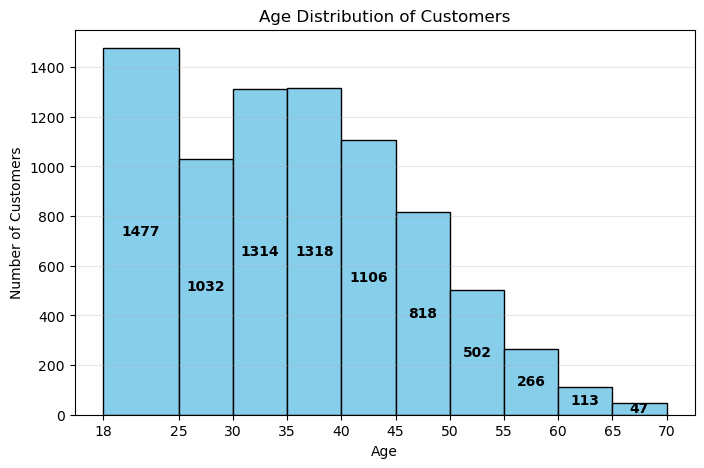

In [7]:
# Define bins. First 18–25, then 5-year intervals up to 70
bins = [18, 25] + list(range(30, 71, 5))

plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df['age'], bins=bins, color='skyblue', edgecolor='black')

# Add text labels inside each bar
for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    plt.text((bin_left + bin_right) / 2, count / 2, str(int(count)),
             ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.xticks(bins)  # Show bin edges on x-axis
plt.grid(axis='y', alpha=0.3)
plt.show()

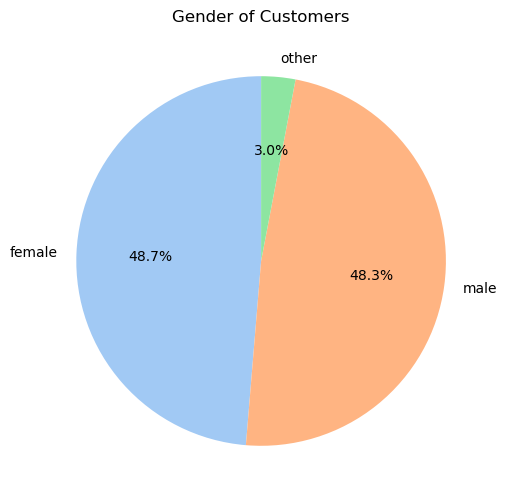

In [8]:
# Number of customers by gender
gender_counts = df['gender'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette("pastel"))

plt.title('Gender of Customers')
plt.show()

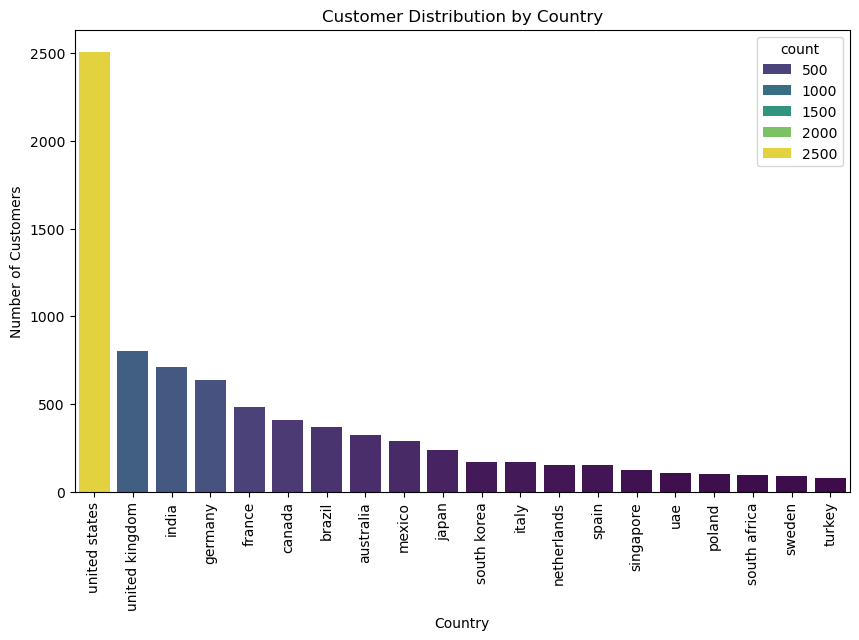

In [9]:
# Count customers by country
country_counts = df['country'].value_counts()

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette="viridis", hue=country_counts)

plt.title('Customer Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=90)  # Rotate labels for readability
plt.show()

In [10]:
# Get countries counts and percent
country_counts = df['country'].value_counts()
country_sum = country_counts.sum()
percent_counts = (country_counts/country_sum) * 100

# Convert to DataFrame for tabular display
country_table = pd.DataFrame({
    'Number of Customers': country_counts.values,
    'Percentage': percent_counts.round(2).astype(str) + '%'
})
print(country_table)

                Number of Customers Percentage
country                                       
united states                  2509     31.36%
united kingdom                  800      10.0%
india                           711      8.89%
germany                         637      7.96%
france                          483      6.04%
canada                          409      5.11%
brazil                          370      4.62%
australia                       323      4.04%
mexico                          288       3.6%
japan                           238      2.97%
south korea                     170      2.12%
italy                           167      2.09%
netherlands                     153      1.91%
spain                           152       1.9%
singapore                       125      1.56%
uae                             106      1.32%
poland                          100      1.25%
south africa                     94      1.18%
sweden                           89      1.11%
turkey       

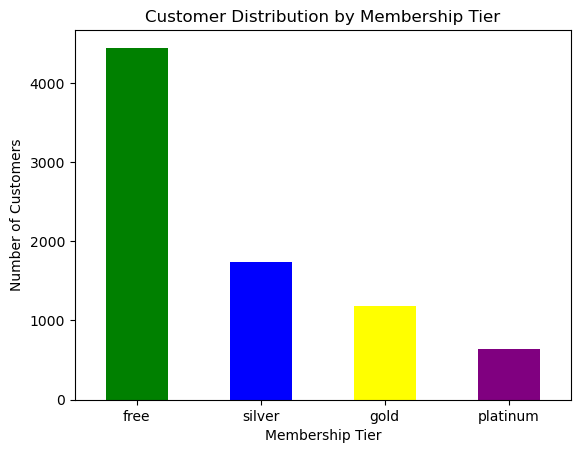

In [11]:
# Count membership tiers
tier_counts = df['membership_tier'].value_counts()

# Plot bar chart
tier_counts.plot(kind='bar', color=['green','blue','yellow','purple'])
plt.title('Customer Distribution by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [12]:
tier_df = pd.DataFrame({
    'Number of members': tier_counts
})
tier_df.T

membership_tier,free,silver,gold,platinum
Number of members,4443,1736,1177,644


 #### Spending and Orders

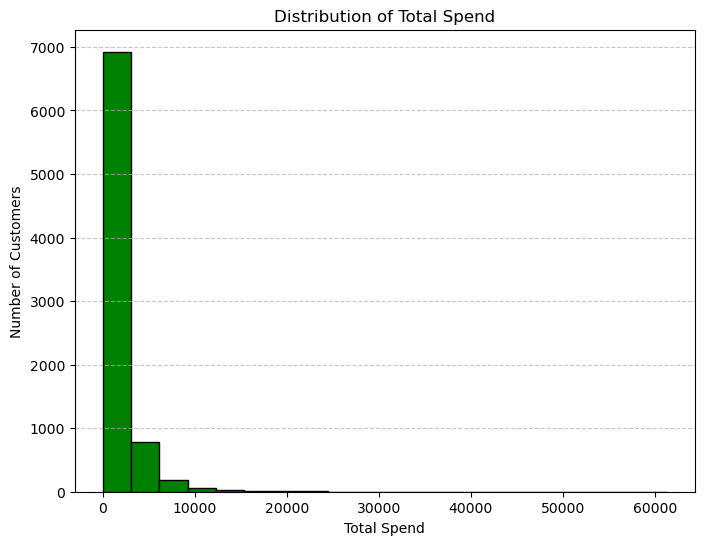

In [13]:
# Histogram of total spend
plt.figure(figsize=(8,6))
plt.hist(df['total_spend_usd'], bins=20, color='green', edgecolor='black')

plt.title('Distribution of Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


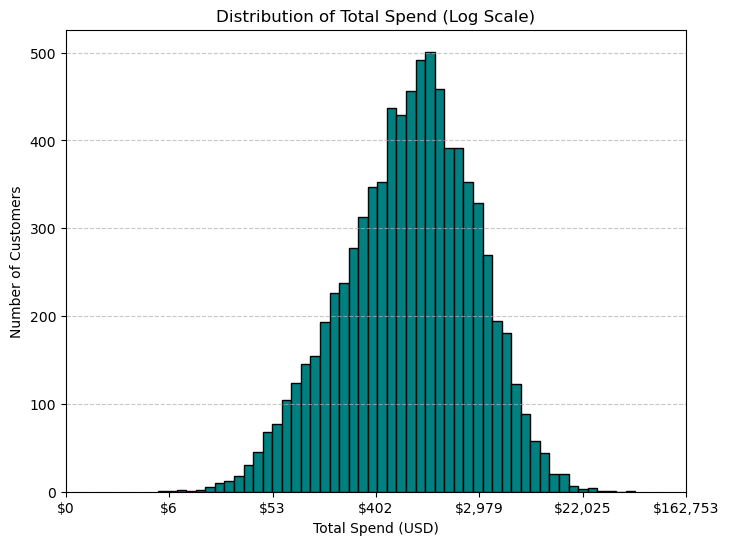

In [14]:
# Due to outliers, we log the data
plt.figure(figsize=(8,6))
plt.hist(np.log1p(df['total_spend_usd']), bins=50, color='teal', edgecolor='black')

plt.title('Distribution of Total Spend (Log Scale)')
plt.xlabel('Total Spend (USD)')
plt.ylabel('Number of Customers')

# Replace log ticks with real USD values
ticks = plt.xticks()[0]
plt.xticks(ticks, [f"${int(np.expm1(t)):,}" for t in ticks])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


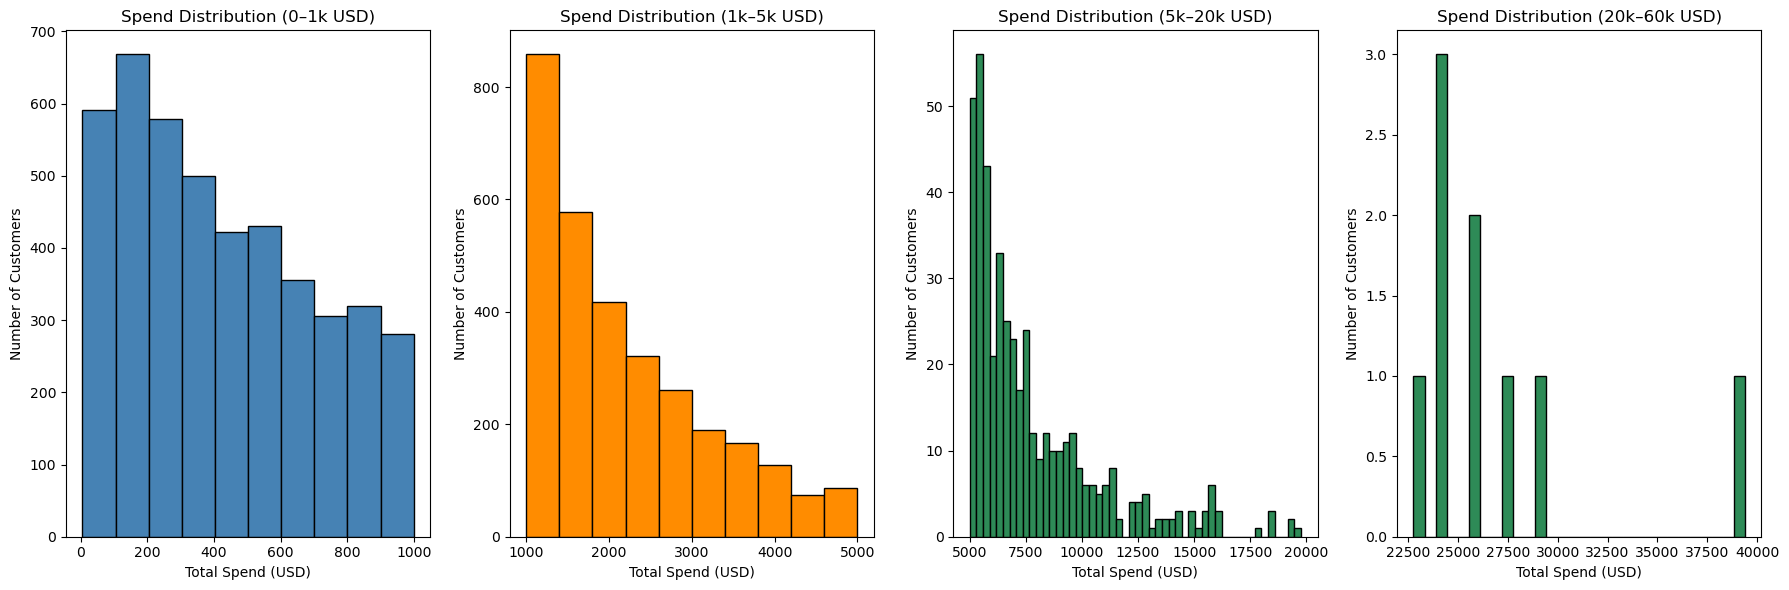

In [15]:
# Split the spend distribution to get clearer insight

fig, axes = plt.subplots(1, 4, figsize=(18,6))

# Range 1: 0–1k
axes[0].hist(df[(df['total_spend_usd'] >= 0) & (df['total_spend_usd'] <= 1000)]['total_spend_usd'],
             bins=10, color='steelblue', edgecolor='black')
axes[0].set_title('Spend Distribution (0–1k USD)')
axes[0].set_xlabel('Total Spend (USD)')
axes[0].set_ylabel('Number of Customers')

# Range 2: 1k–5k
axes[1].hist(df[(df['total_spend_usd'] > 1001) & (df['total_spend_usd'] <= 5000)]['total_spend_usd'],
             bins=10, color='darkorange', edgecolor='black')
axes[1].set_title('Spend Distribution (1k–5k USD)')
axes[1].set_xlabel('Total Spend (USD)')
axes[1].set_ylabel('Number of Customers')

# Range 3: 5k–20k
axes[2].hist(df[(df['total_spend_usd'] > 5001) & (df['total_spend_usd'] <= 20000)]['total_spend_usd'],
             bins=50, color='seagreen', edgecolor='black')
axes[2].set_title('Spend Distribution (5k–20k USD)')
axes[2].set_xlabel('Total Spend (USD)')
axes[2].set_ylabel('Number of Customers')

# Range 4: 20k–60k
axes[3].hist(df[(df['total_spend_usd'] > 20001) & (df['total_spend_usd'] <= 60000)]['total_spend_usd'],
             bins=30, color='seagreen', edgecolor='black')
axes[3].set_title('Spend Distribution (20k–60k USD)')
axes[3].set_xlabel('Total Spend (USD)')
axes[3].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

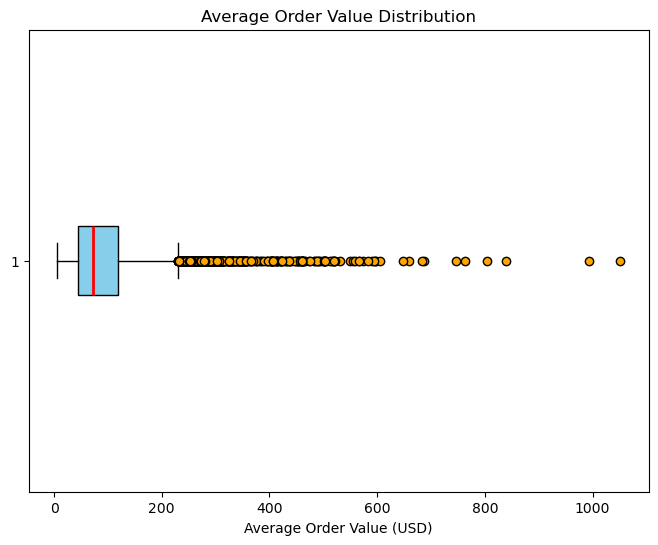

In [16]:
plt.figure(figsize=(8,6))
plt.boxplot(df['avg_order_value_usd'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markerfacecolor='orange', markersize=6))

plt.title('Average Order Value Distribution')
plt.xlabel('Average Order Value (USD)')
plt.show()

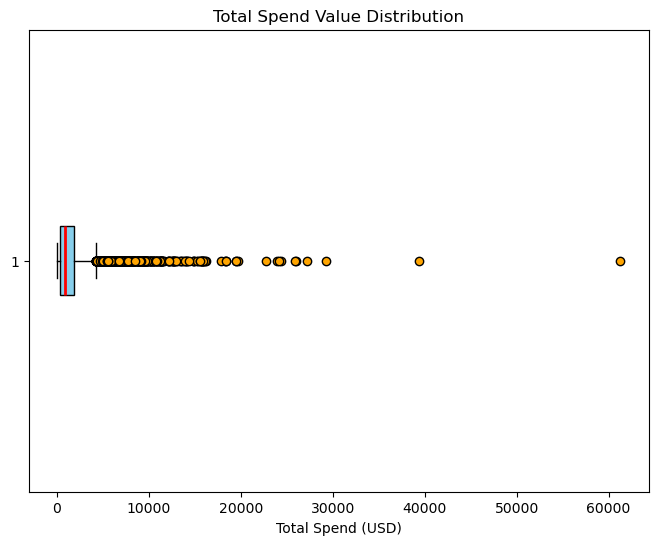

In [17]:
plt.figure(figsize=(8,6))
plt.boxplot(df['total_spend_usd'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markerfacecolor='orange', markersize=6))

plt.title('Total Spend Value Distribution')
plt.xlabel('Total Spend (USD)')
plt.show()

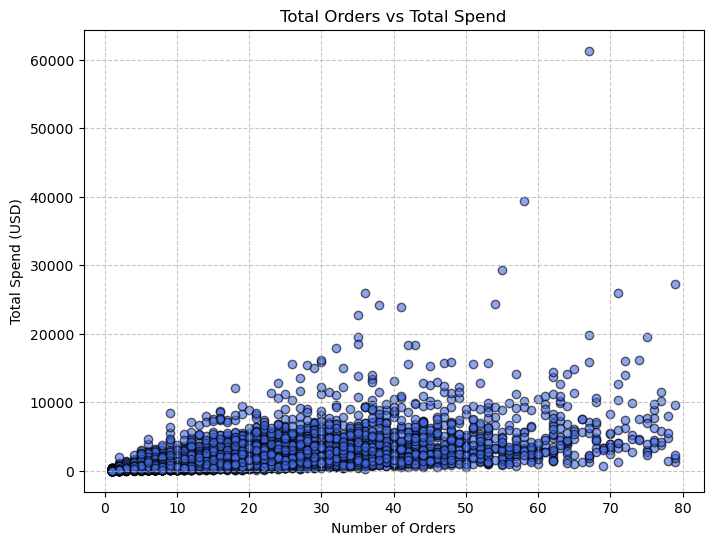

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(df['total_orders'], df['total_spend_usd'], alpha=0.6, color='royalblue', edgecolors='black')

plt.title('Total Orders vs Total Spend')
plt.xlabel('Number of Orders')
plt.ylabel('Total Spend (USD)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

#### Engagement and Activity

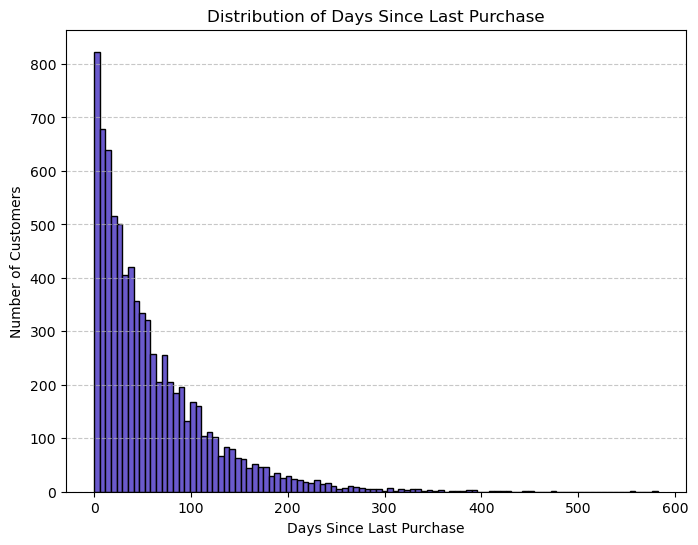

In [19]:
plt.figure(figsize=(8,6))
plt.hist(df['days_since_last_purchase'], bins=100, color='slateblue', edgecolor='black')

plt.title('Distribution of Days Since Last Purchase')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

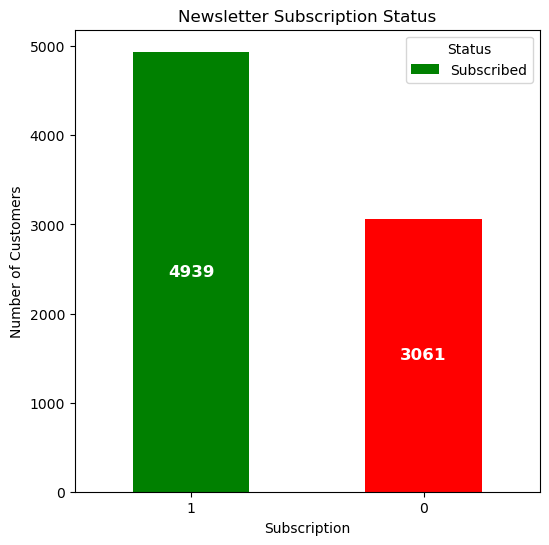

In [20]:
# Count subscription status
subscription_counts = df['newsletter_subscribed'].value_counts()

# Plot bar chart
ax = subscription_counts.plot(kind='bar', color=['green','red'], figsize=(6,6))

plt.title('Newsletter Subscription Status')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.legend(title='Status', labels=['Subscribed'])
plt.xticks(rotation=0)

# Add numbers inside bars
for i, value in enumerate(subscription_counts.values):
    ax.text(i, value/2, str(value), ha='center', va='center', color='white', fontsize=12, fontweight='bold')

plt.show()

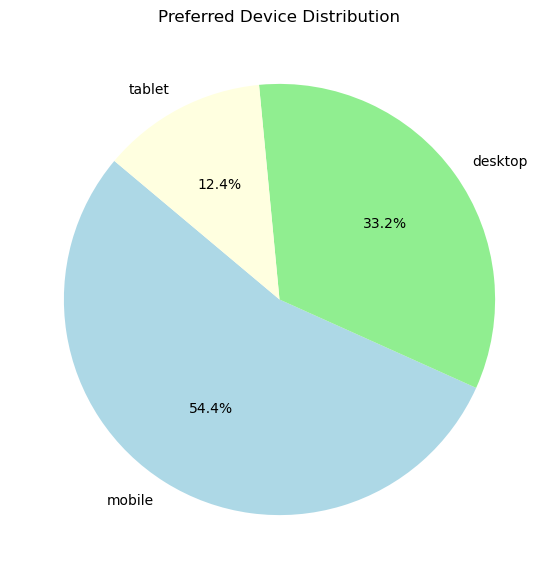

In [21]:
# Count preferred devices
device_counts = df['preferred_device'].value_counts()

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=['lightblue','lightgreen','lightyellow','purple'])

plt.title('Preferred Device Distribution')
plt.show()

#### Preferences and Behaviour

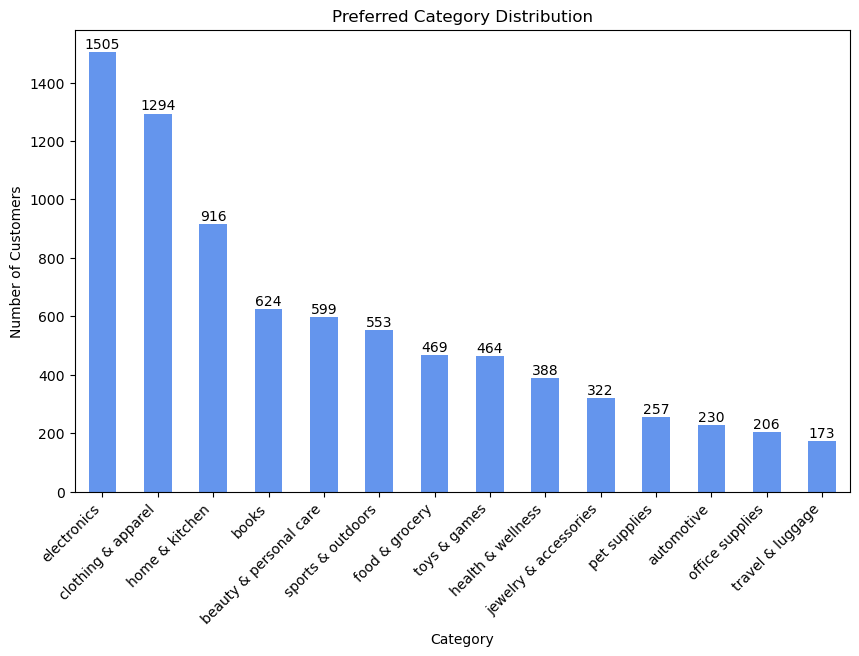

In [22]:
# Count preferred categories
category_counts = df['preferred_category'].value_counts()

# Plot bar chart
ax = category_counts.plot(kind='bar', color='cornflowerblue', figsize=(10,6))

plt.title('Preferred Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')

# Add counts above bars
for i, value in enumerate(category_counts.values):
    ax.text(i, value + 2, str(value), ha='center', va='bottom', fontsize=10)

plt.show()

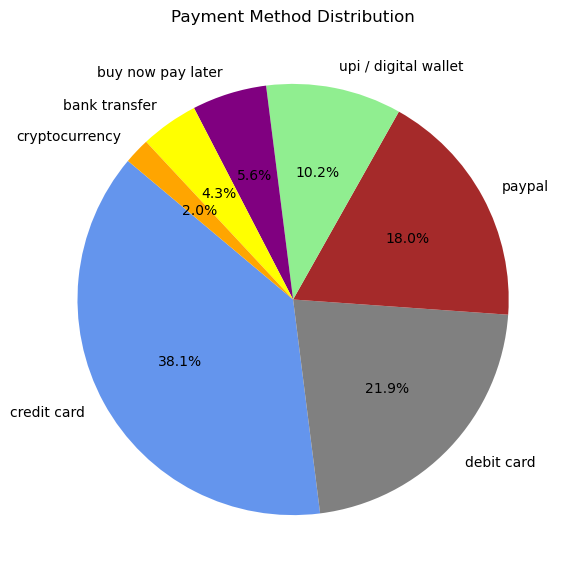

In [23]:
# Count payment methods
payment_counts = df['preferred_payment_method'].value_counts()

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['cornflowerblue', 'gray','brown','lightgreen','purple','yellow', 'orange'])

plt.title('Payment Method Distribution')
plt.show()


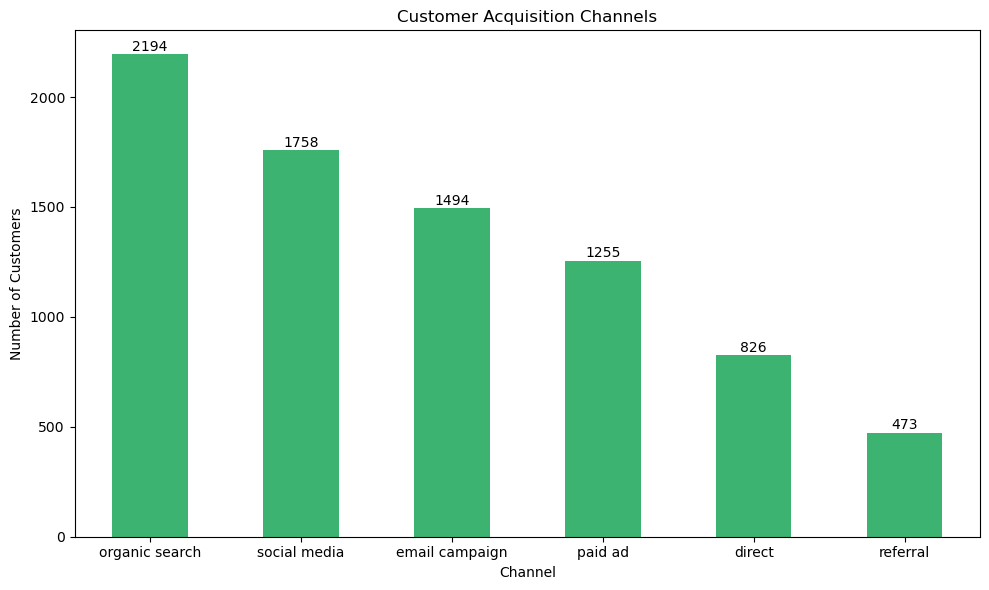

In [24]:
# Count acquisition channels
channel_counts = df['acquisition_channel'].value_counts()

# Plot bar chart
ax = channel_counts.plot(kind='bar', color='mediumseagreen', figsize=(10,6))

plt.title('Customer Acquisition Channels')
plt.xlabel('Channel')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0, ha='center')

# Add counts above bars
for i, value in enumerate(channel_counts.values):
    ax.text(i, value + 2, str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


#### Churn and Retention

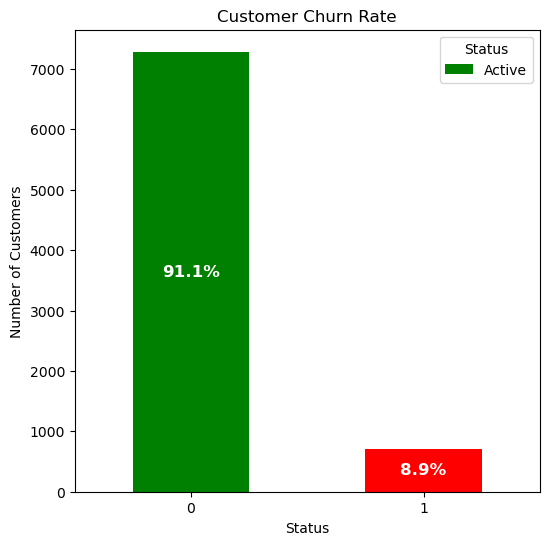

In [25]:
# Count churn status
churn_counts = df['churned'].value_counts()

# Plot bar chart
ax = churn_counts.plot(kind='bar', color=['green','red'], figsize=(6,6))

plt.title('Customer Churn Rate')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.legend(title='Status', labels=['Active'])
plt.xticks(rotation=0)

# Add percentage labels
total = churn_counts.sum()
for i, value in enumerate(churn_counts.values):
    percent = (value/total)*100
    ax.text(i, value/2, f"{percent:.1f}%", ha='center', va='center', 
            color='white', fontsize=12, fontweight='bold')

plt.show()

In [26]:
churn_counts = df['churned'].value_counts()
churn_counts

churned
0    7285
1     715
Name: count, dtype: int64

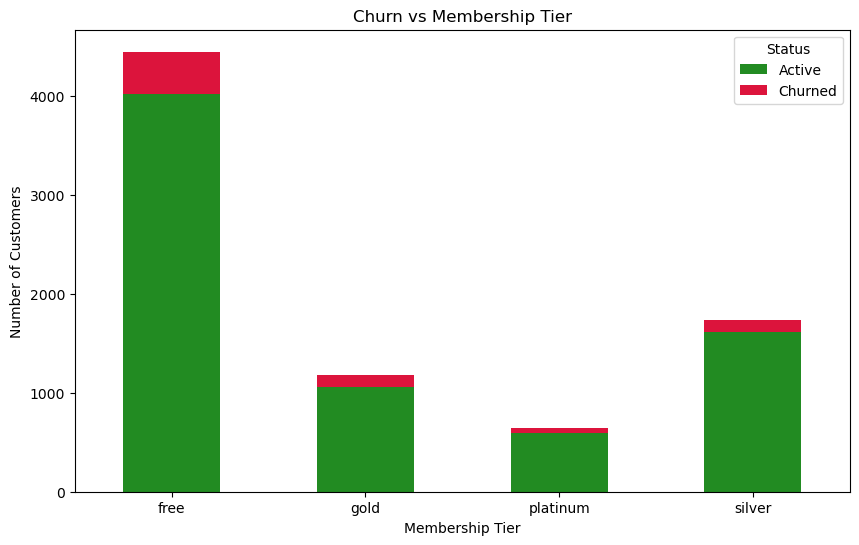

In [27]:
# Create grouped counts
churn_tier_counts = df.groupby(['membership_tier','churned']).size().unstack()

# Plot bar chart
churn_tier_counts.plot(kind='bar', stacked=True, color=['forestgreen','crimson'], figsize=(10,6))

plt.title('Churn vs Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Active','Churned'])

plt.show()

In [28]:
df.groupby('membership_tier')['churned'].value_counts()

# Replace 0 with 'Active' and 1 with 'Inactive'
df['churn_status'] = df['churned'].replace({0: 'Active', 1: 'Inactive'})

# Now run your groupby
result = df.groupby('membership_tier')['churn_status'].value_counts()
resulted = pd.DataFrame({
    'Numbers of customers': result
})
resulted

Numbers of customers
membership_tier churn_status                      
free            Active                        4020
                Inactive                       423
gold            Active                        1061
                Inactive                       116
platinum        Active                         591
                Inactive                        53
silver          Active                        1613
                Inactive                       123

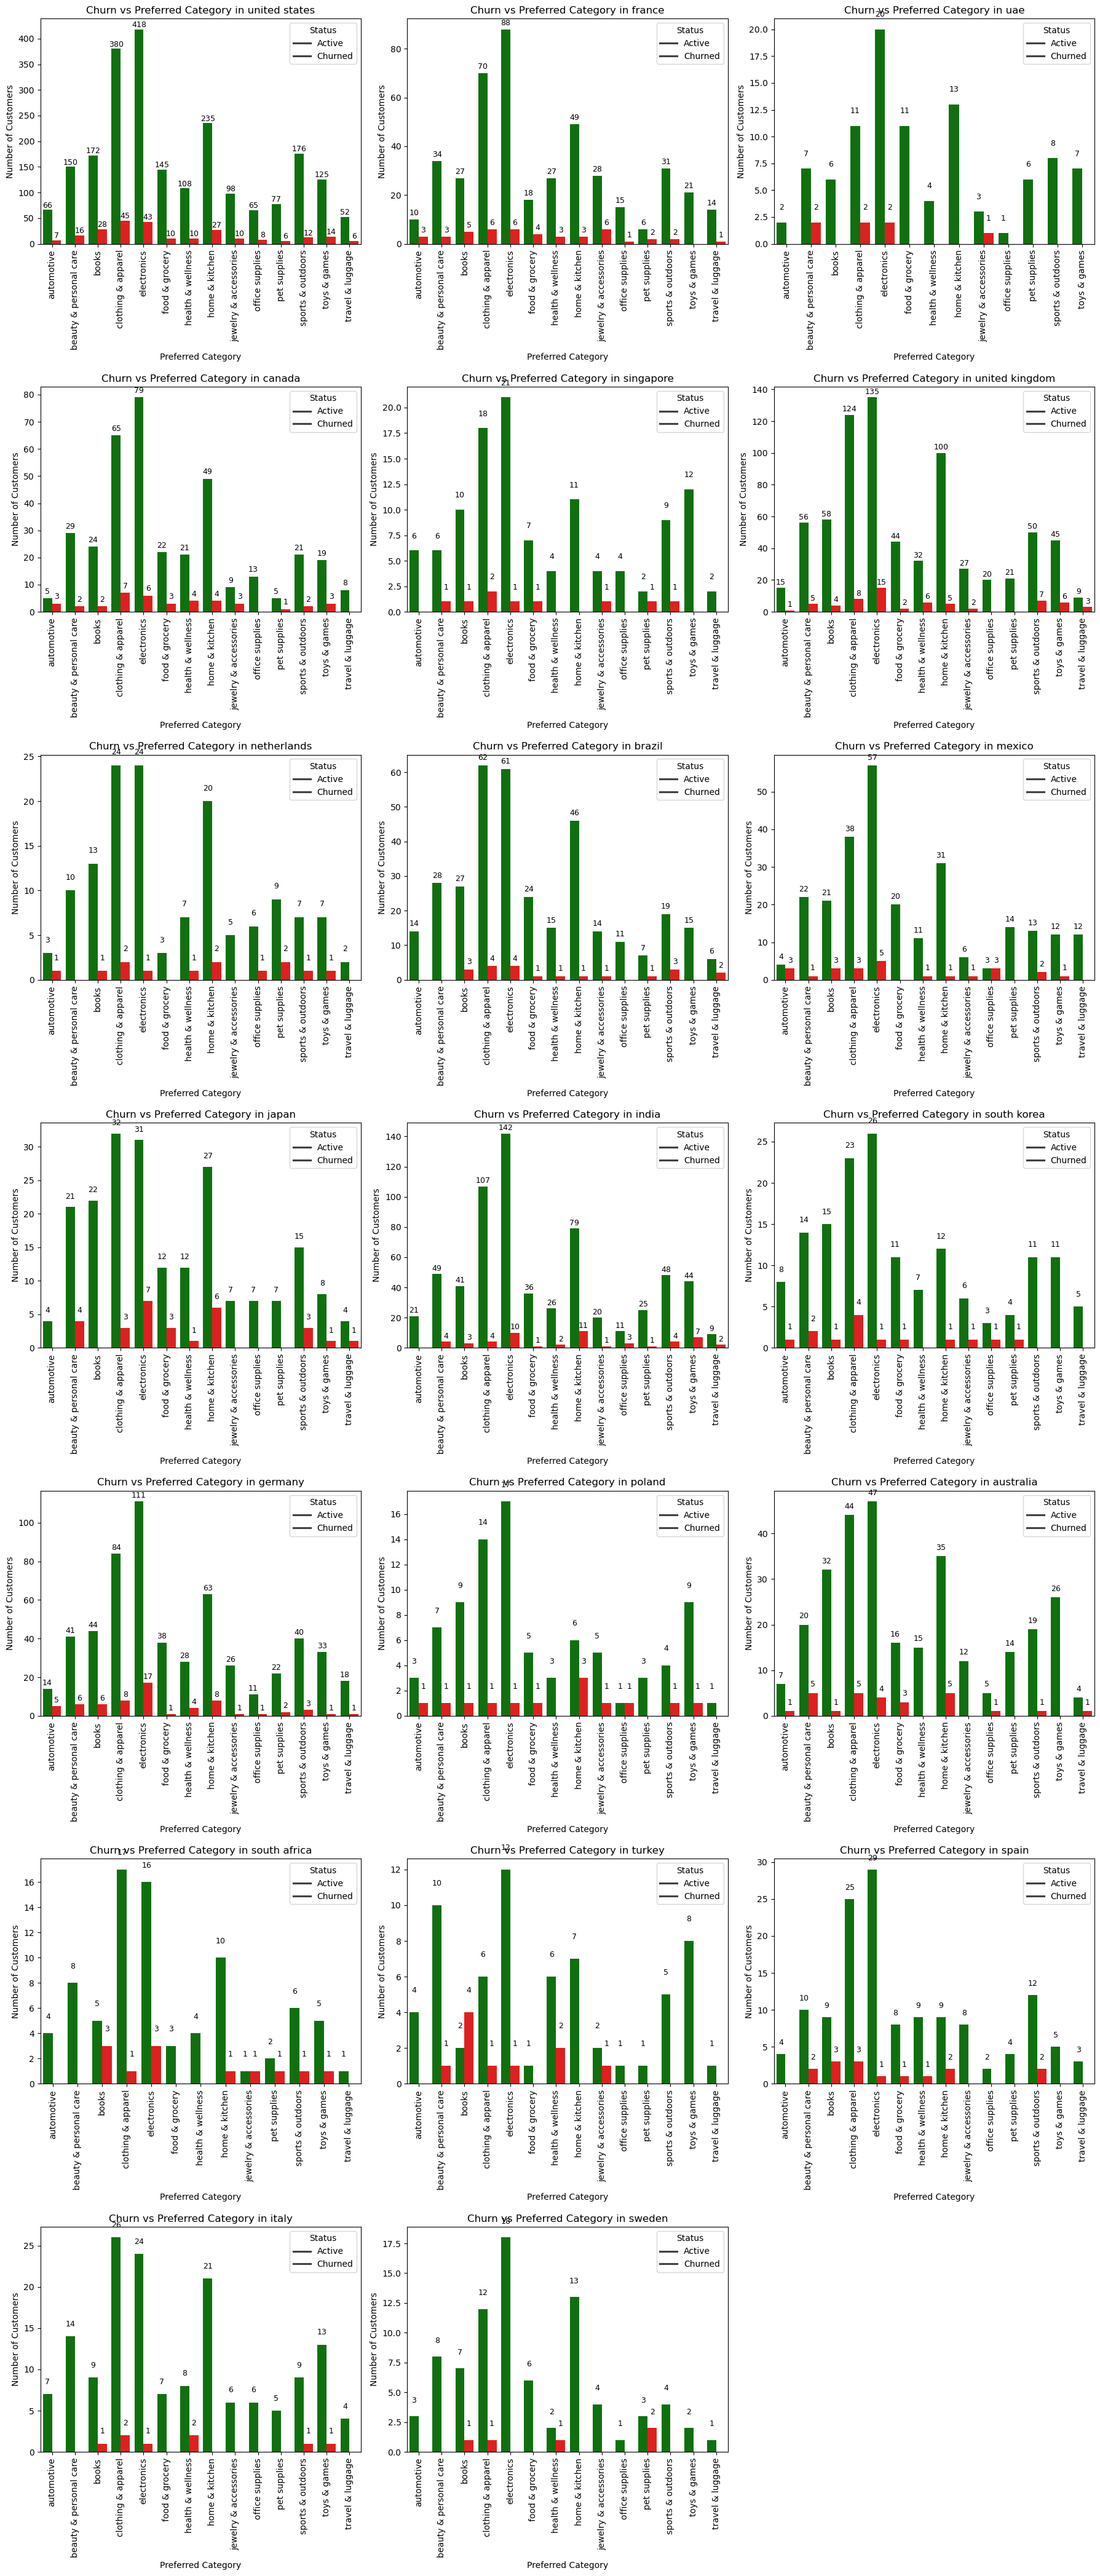

In [29]:
import math
# Get unique countries
countries = df['country'].unique()
n_countries = len(countries)

# Define grid: 3 charts per row
n_cols = 3
n_rows = math.ceil(n_countries / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows), sharey=False)
axes = axes.flatten()

for i, country in enumerate(countries):
    subset = df[df['country'] == country]
    churn_category_counts = subset.groupby(['preferred_category','churned']).size().reset_index(name='count')
    
    ax = axes[i]
    sns.barplot(data=churn_category_counts, x='preferred_category', y='count', hue='churned', palette=['green','red'], ax=ax)
    
    ax.set_title(f'Churn vs Preferred Category in {country}')
    ax.set_xlabel('Preferred Category')
    ax.set_ylabel('Number of Customers')
    ax.tick_params(axis='x', rotation=90)
    ax.legend(title='Status', labels=['Active','Churned'])
    
    # Add whole number labels above bars
    for p in ax.patches:
        height = int(p.get_height())  # convert to integer
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2, height + 1, str(height),
                    ha='center', va='bottom', fontsize=9)

# Hide unused subplot axes
for unused in range(i+1, len(axes)):
    fig.delaxes(axes[unused])

plt.tight_layout()
plt.show()

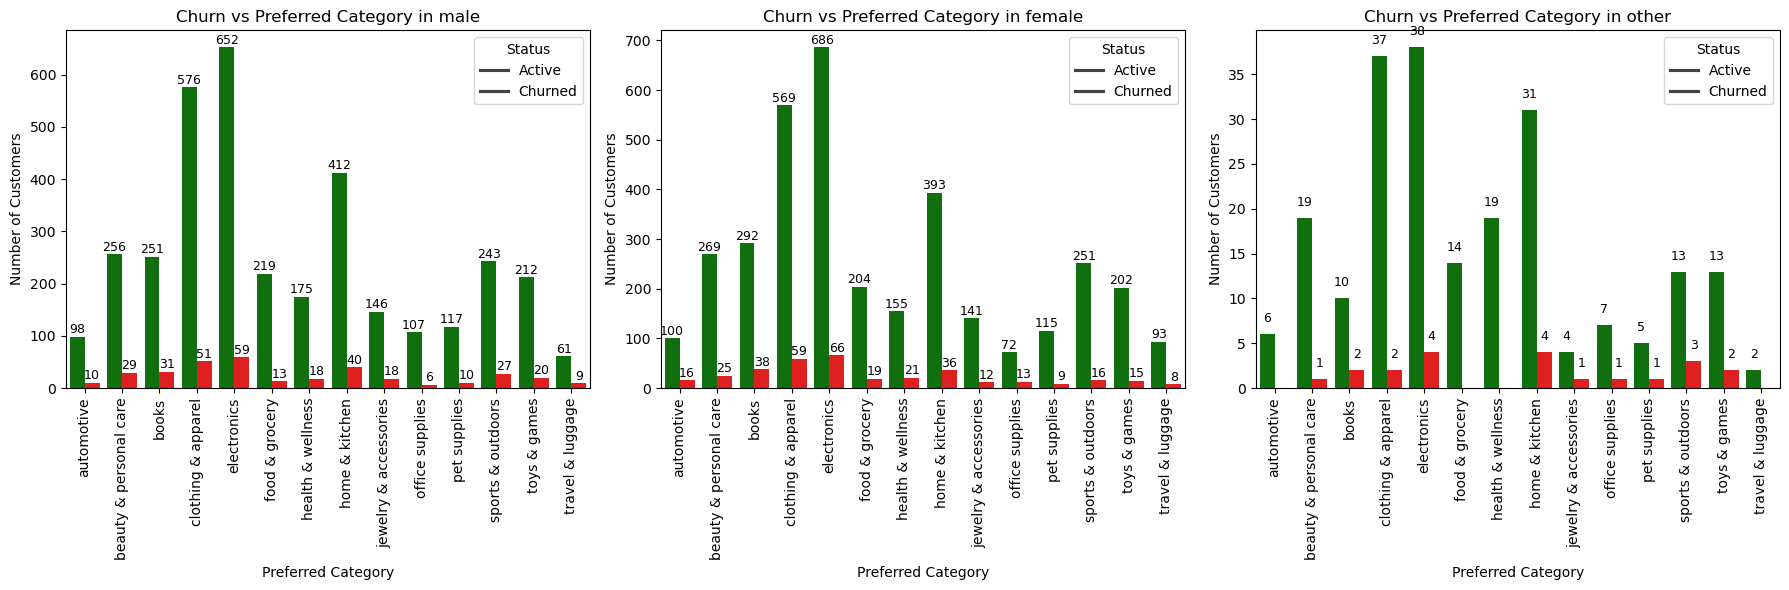

In [30]:
# Get unique gender
genders = df['gender'].unique()
n_genders = len(genders)

# Define grid: 3 charts per row
n_cols = 3
n_rows = math.ceil(n_genders / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows), sharey=False)
axes = axes.flatten()

for i, gender in enumerate(genders):
    subset = df[df['gender'] == gender]
    churn_category_counts = subset.groupby(['preferred_category','churned']).size().reset_index(name='count')
    
    ax = axes[i]
    sns.barplot(data=churn_category_counts, x='preferred_category', y='count', hue='churned', palette=['green','red'], ax=ax)
    
    ax.set_title(f'Churn vs Preferred Category in {gender}')
    ax.set_xlabel('Preferred Category')
    ax.set_ylabel('Number of Customers')
    ax.tick_params(axis='x', rotation=90)
    ax.legend(title='Status', labels=['Active','Churned'])
    
    # Add whole number labels above bars
    for p in ax.patches:
        height = int(p.get_height())  # convert to integer
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2, height + 1, str(height),
                    ha='center', va='bottom', fontsize=9)

# Hide unused subplot axes
for unused in range(i+1, len(axes)):
    fig.delaxes(axes[unused])

plt.tight_layout()
plt.show()

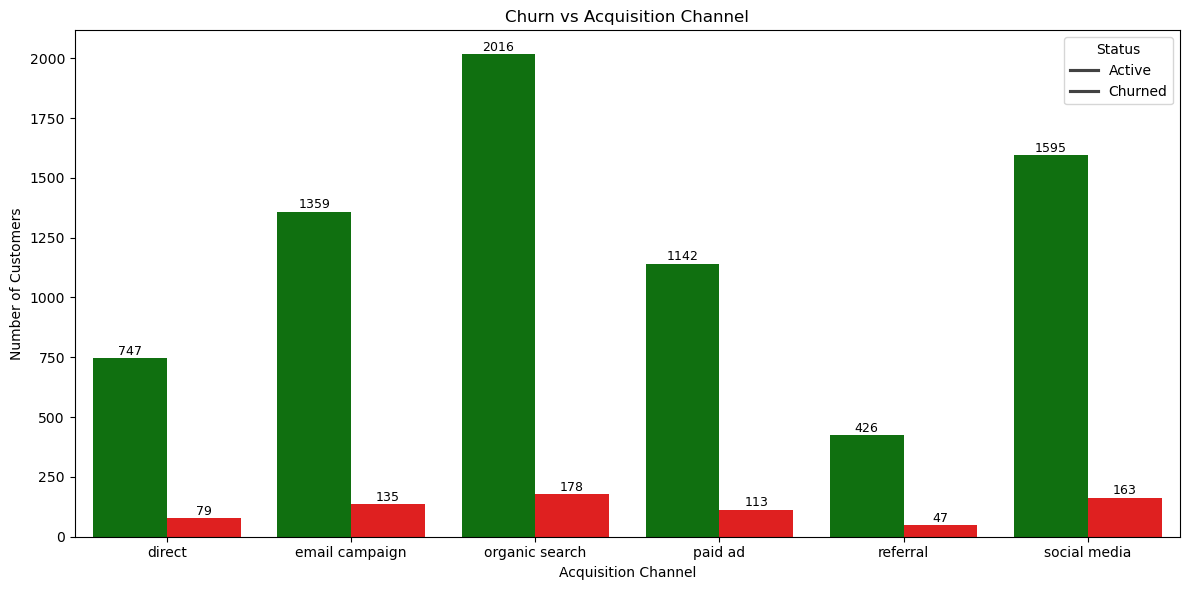

In [31]:
# Group by acquisition_channel and churned
churn_acquisition_counts = df.groupby(['acquisition_channel','churned']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=churn_acquisition_counts, x='acquisition_channel', y='count', hue='churned', palette=['green','red'])

plt.title('Churn vs Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Active','Churned'])

# Add whole number labels above bars
for p in plt.gca().patches:
    height = int(p.get_height())
    if height > 0:
        plt.gca().text(p.get_x() + p.get_width()/2, height + 1, str(height),
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


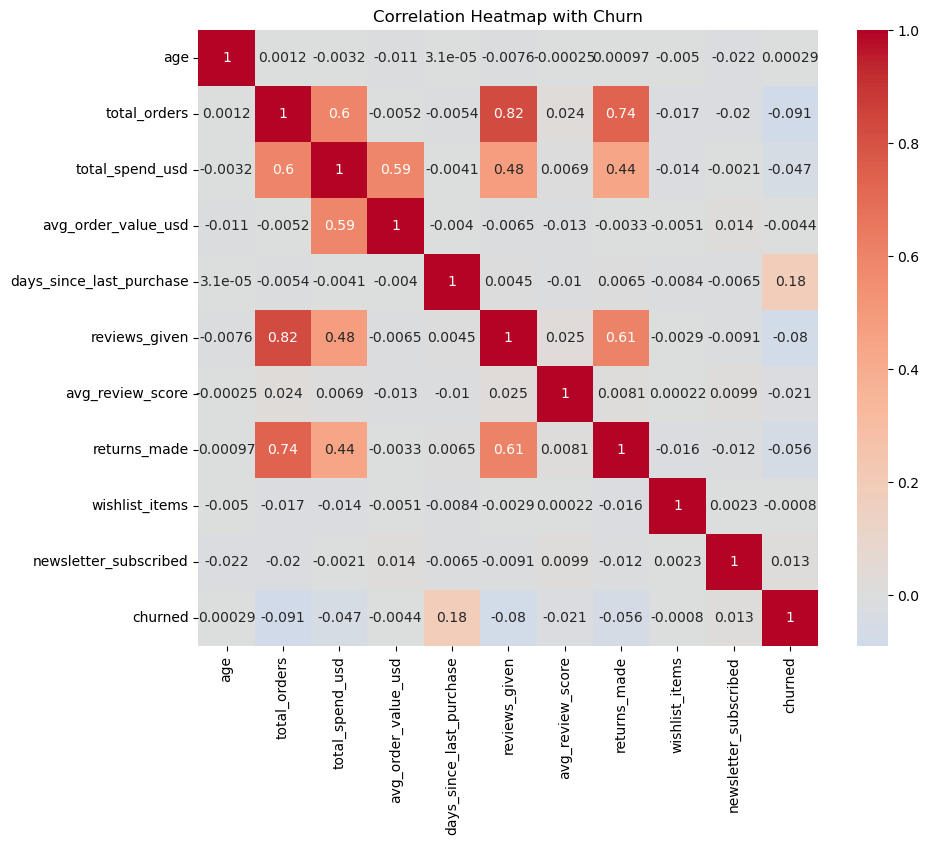

In [32]:
# HeatMap
numeric_cols = ['age', 'total_orders',	'total_spend_usd',	'avg_order_value_usd', 'days_since_last_purchase',	'reviews_given',	'avg_review_score',	'returns_made',	'wishlist_items',	'newsletter_subscribed']
corr = df[numeric_cols + ['churned']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap with Churn')
plt.show()

In [33]:
# correlations

# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# numeric_cols

# Compute correlation with churned
correlations = df[numeric_cols].corr()['churned'].sort_values(ascending=False)
print(correlations)

# this also works well
# numeric_cols = ['age','total_orders','total_spend_usd','avg_order_value_usd', 'days_since_last_purchase','reviews_given','avg_review_score', 'returns_made','wishlist_items']
# correlations = df[numeric_cols + ['churned']].corr()['churned'].sort_values(ascending=False)
# print(correlations)

churned                     1.000000
days_since_last_purchase    0.182782
newsletter_subscribed       0.013141
age                         0.000286
wishlist_items             -0.000798
avg_order_value_usd        -0.004437
avg_review_score           -0.020585
total_spend_usd            -0.046662
returns_made               -0.056167
reviews_given              -0.079637
total_orders               -0.090522
Name: churned, dtype: float64


In [34]:
# For categorical variables

import scipy.stats as stats

categorical_cols = ['country','gender','membership_tier','preferred_category',
                    'preferred_device','preferred_payment_method','acquisition_channel',
                    'newsletter_subscribed']

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['churned'])
    chi2, p, dof, ex = stats.chi2_contingency(contingency)
    print(f"{col}: p-value={p:.4f}")

country: p-value=0.1444
gender: p-value=0.9291
membership_tier: p-value=0.0129
preferred_category: p-value=0.5689
preferred_device: p-value=0.1117
preferred_payment_method: p-value=0.2246
acquisition_channel: p-value=0.6881
newsletter_subscribed: p-value=0.2563
